
## **Notebook Overview — Fixed-Effects Decomposition and Bootstrap**

 **Purpose:**
 This notebook estimates a fixed-effects (FE) model to decompose SES-related differences in essay scores  
 into *content*, *style*, and *other* components, and optionally computes bootstrap confidence intervals.

**How to Use:**
 - **Run up to Cell 3** if you only need the **decomposition dataset**:  
   This will fit the FE model once, append the fixed effects (`fe_essay`, `fe_k`) and residuals (`u`)  
   to each observation, and save the full augmented dataset as a CSV file.  
   --> Output file: `decomp_rows_with_fe.csv`

 - **Run all cells (1–7)** if you also want to **compute bootstrap confidence intervals**:  
   This will perform 500 clustered bootstrap replications at the essay level (resampling essays  
   with all rewrites), re-estimate the FE model each time, and produce percentile-based 95% CIs  
   for the total, content, style, and others decomposition metrics.

 **Outputs:**
 - `decomp_rows_with_fe.csv` --> Row-level data with FE components for all essays and rewrites.  
 - `summary_df` --> Compact table with decomposition point estimates and bootstrap 95% CIs (Both in .csv and .tex formats).

### **Cell 1 — Imports & Configuration**

**Purpose:**
- Import all core Python libraries used throughout the notebook.  
- Prepare tools for data handling (`pandas`, `numpy`), model estimation (`pyfixest`), and progress visualization (`tqdm`).  
- Include utilities for parallel computation (`joblib`) and statistical modeling (`statsmodels`).  
- Initialize a global random number generator (`rng`) with a fixed seed to ensure reproducibility of bootstrap samples.


In [1]:
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from joblib import Parallel, delayed
import statsmodels.api as sm
from pyfixest.estimation import feols

# Reproducibility
rng = np.random.default_rng(42)

In [2]:
out_path = "../../output/"

table_out_path = "../../output/tables/"

df_path = "../../data/results/sat_full/data_sat_scored.csv"



### **Cell 2 — Load & Basic Preparation**

**Purpose:**
- Load the scored dataset containing essay-level and rewrite-level information.  
- Sort rows by `essay_id` and `k` so each essay’s rewrites appear sequentially, ensuring consistent ordering for later fixed-effect estimation and bootstrapping.  
- Reset the index to maintain a clean 0–N row index after sorting.


In [3]:
df = pd.read_csv(df_path, encoding="ISO-8859-1", index_col=0)

df = df.sort_values(["essay_id","k"]).reset_index(drop=True)

### **Cell 3 — Fit Fixed-Effects Model and Extract Baseline Estimates**

**Purpose:**
- Estimate a two-way fixed-effects model using `pyfixest` to control for essay-specific and prompt-specific variation.  
- Model specification: `score_high_full ~ 1 | essay_id + k`.  
- Retrieve the estimated fixed effects from the model output (`fes`):  
  - `fe_essay` → captures essay-level (content) differences.  
  - `fe_k` → captures prompt-level (context) effects.  
- Map these fixed effects back to each observation in the DataFrame for later decomposition.  
- Compute residuals `u = score_high_full – fe_essay`, representing the style component once essay-level effects are removed.


In [4]:
# FE regression
res = feols("score_high_full ~ 1 | essay_id + k", data=df[df['k']!=0])
print(res.summary)

fes = res.fixef()
fe_essay_map = fes["C(essay_id)"]  #
fe_k_map = fes["C(k)"]

# Map back to rows
df["fe_essay"] = df["essay_id"].map(fe_essay_map)
df["fe_k"] = df["k"].map(fe_k_map)

# Style residual (after removing essay FE only, as in your code)
df["u"] = df["score_high_full"] - df["fe_essay"]

# Compute diff column
df["diff"] = df["score_high_full"] - df["score_low_full"]

# Save DataFrame with FEs and residuals
df.to_csv(out_path + "decomp_rows_with_fe.csv", index=False)
print(f"Saved augmented dataset - {out_path}decomp_rows_with_fe.csv")

functools.partial(<function summary at 0x13afef4c0>, models=[<pyfixest.estimation.feols_.Feols object at 0x13ada5b50>])
Saved augmented dataset - ../../output/decomp_rows_with_fe.csv


In [5]:
# Define a small utility function to compute conditional means while safely handling missing values (`NaN`). 

def mean_mask(s: pd.Series, mask: pd.Series) -> float:
    s2 = s[mask & s.notna()]
    return float(s2.mean()) if len(s2) else np.nan


### **Cell 4 — Decomposition**

**Purpose:**
- Compute the SES gap and its decomposition into **content**, **style**, and **others** using the FE outputs.  
- Restrict the decomposition to **k == 0** for comparability.  
- Return both **absolute gaps** and **shares** (each component divided by the total gap).

**Steps:**
 - **A) Total gap (k==0):**  
   - Group 0 = high-SES `score_high_full` where `low_SES==0`.  
   - Group 1 = low-SES  `score_low_full`  where `low_SES==1`.  
   - `total_gap = mean(group 0) – mean(group 1)`.
 - **B) Content gap (k==0):**  
   - Compare `fe_essay` means between SES groups; essay FE proxies content.  
   - `content_gap = mean(fe_essay | high-SES) – mean(fe_essay | low-SES)`.
 - **C) Style gap (k==0):**  
   - Use residual `u = score_high_full – fe_essay` as a style proxy.  
   - `style_gap = mean(u | high-SES) – mean(u | low-SES)`.
 - **D) Others gap (k==0, within high-SES):**  
   - Difference between `score_high_full` and `score_low_full` (same SES group).  
   - `others_gap = mean(score_high_full) – mean(score_low_full)` for `low_SES==0`.

**Outputs:**
 - Dictionary with absolute gaps: `total_gap`, `content_gap`, `style_gap`, `others_gap`.  
 - Shares: `share_content`, `share_style`, `share_others` (component / total_gap).  
 - `point_est` stores the baseline (non-bootstrap) decomposition for the full sample.

In [ ]:
def compute_decomposition_point_estimates(df_in: pd.DataFrame):
    df_ = df_in.copy()

    # --- A) total gap (k==0)
    mA = (df_["low_SES"]==0) & (df_["k"]==0) & df_["score_high_full"].notna()
    mB = (df_["low_SES"]==1) & (df_["k"]==0) & df_["score_low_full"].notna()
    tmp_vals = pd.Series(np.nan, index=df_.index)
    tmp_vals[mA] = df_.loc[mA, "score_high_full"].astype(float)
    tmp_vals[mB] = df_.loc[mB, "score_low_full"].astype(float)

    group = pd.Series(np.nan, index=df_.index)
    group[mA] = 0
    group[mB] = 1

    m0 = (group==0)
    m1 = (group==1)

    mean0 = mean_mask(tmp_vals, m0)
    mean1 = mean_mask(tmp_vals, m1)
    total_gap = mean0 - mean1

    # --- B) content gap (k==0), use essay FE
    mK0 = (df_["k"]==0)
    content_mean0 = mean_mask(df_["fe_essay"], mK0 & (df_["low_SES"]==0))
    content_mean1 = mean_mask(df_["fe_essay"], mK0 & (df_["low_SES"]==1))
    content_gap = content_mean0 - content_mean1

    # --- C) style gap via residual u = score_high_full - fe_essay
    u_mean0 = mean_mask(df_["u"], mK0 & (df_["low_SES"]==0))
    u_mean1 = mean_mask(df_["u"], mK0 & (df_["low_SES"]==1))
    style_gap = u_mean0 - u_mean1

    # --- D) others gap (your original "diff" within high-SES at k==0)
    # --- D) ranker-tilting (on low-SES originals at k==0)
    m_tilt = (df_["low_SES"]==1) & (df_["k"]==0)
    others_gap = mean_mask(df_["score_high_full"] - df_["score_low_full"], m_tilt)

    return {
        "total_gap": total_gap,
        "content_gap": content_gap,
        "style_gap": style_gap,
        "others_gap": others_gap,
        "share_content": content_gap/total_gap if pd.notna(total_gap) and total_gap!=0 else np.nan,
        "share_style": style_gap/total_gap   if pd.notna(total_gap) and total_gap!=0 else np.nan,
        "share_others": others_gap/total_gap  if pd.notna(total_gap) and total_gap!=0 else np.nan,
    }

point_est = compute_decomposition_point_estimates(df)
point_est


{'total_gap': 0.6633067342986796,
 'content_gap': 0.4560656086433972,
 'style_gap': 0.1730503395222922,
 'others_gap': 0.03419078613298989,
 'share_content': 0.6875636640800875,
 'share_style': 0.26089037028285256,
 'share_others': 0.051545965637059495}

In [7]:
df.to_csv(out_path + "decomp_rows_with_fe.csv", index=False)


### **Cell 5 — Bootstrap (Clustered at essay_id; Parallelized, 500 Reps, 2.5–97.5% CI)**

**Purpose:**
- Estimate uncertainty for the decomposition metrics using **clustered bootstrapping** at the essay level.  
- Each bootstrap sample resamples essays (clusters) **with replacement**, keeping all their rewrites together.  
- The process re-fits the fixed-effects model on each resample, computes the decomposition again,  
  and aggregates results across 500 iterations to form **95% confidence intervals**.

**Steps:**
1. Reset DataFrame index and precompute a dictionary mapping each `essay_id` to its row indices  
2. Define the helper function `one_rep(seed)` that performs a **single bootstrap iteration**:  
   - Samples `essay_id`s with replacement (cluster bootstrap).  
   - Extracts the corresponding rows efficiently via `.iloc`.  
   - Re-fits the FE model (`score_high_full ~ 1 | essay_id + k`).  
   - Computes essay and prompt fixed effects, residuals, and decomposition metrics.  
3. Generate a list of independent random seeds (one per iteration) to ensure reproducibility  
   across parallel workers.  
4. Use **Joblib’s `Parallel`** and **`delayed`** utilities to run all 500 bootstrap replications concurrently  
   (`n_jobs=-1` automatically uses all available CPU cores).  
5. Convert the resulting list of dictionaries into a single DataFrame (`boot_df_stats`),  
   where each row corresponds to one bootstrap iteration and each column to a decomposition metric.  
6. Compute percentile-based confidence intervals (2.5% and 97.5%) for every statistic,  
   storing them in `ci_bounds` as a compact dictionary of lower–upper tuples.


In [8]:
B = 500  # number of bootstrap iterations


def run_bootstrap_for_group(df_group: pd.DataFrame, group_label: str, B: int = 500, seed: int = 42):
    """
    Runs the same bootstrap you already have, but restricted to df_group.
    Returns a list of rows (dicts) for this group, ready to concat into summary_df.
    """

    # --- Rebuild essay clusters inside the group ---
    df_g = df_group.reset_index(drop=True)
    essay_to_idx_g = df_g.groupby("essay_id").indices
    essay_ids_g = np.array(list(essay_to_idx_g.keys()))
    n_clusters_g = len(essay_ids_g)

    # Edge case: if group has too few essays, skip
    if n_clusters_g < 2:
        print(f"Skipping group {group_label}: only {n_clusters_g} distinct essays.")
        return []

    rng = np.random.default_rng(seed)
    seeds = rng.integers(0, 2**32 - 1, size=B, dtype=np.uint64)

    def one_rep_group(s: int) -> dict:
        """
        One bootstrap iteration for THIS group only.
        Same logic as your existing one_rep, but using df_g and essay_to_idx_g.
        """
        rng_local = np.random.default_rng(s)

        sampled = rng_local.choice(essay_ids_g, size=n_clusters_g, replace=True)
        idx = np.concatenate([essay_to_idx_g[eid] for eid in sampled])

        df_b = df_g.iloc[idx].copy()

        res_b = feols("score_high_full ~ 1 | essay_id + k", data=df_b[df_b['k']!=0])

        fes_b = res_b.fixef()
        fe_essay_b = fes_b["C(essay_id)"]
        fe_k_b = fes_b["C(k)"]

        df_b["fe_essay"] = df_b["essay_id"].map(fe_essay_b)
        df_b["fe_k"] = df_b["k"].map(fe_k_b)
        df_b["u"] = df_b["score_high_full"] - df_b["fe_essay"]

        return compute_decomposition_point_estimates(df_b)

    print(f"Running {B} bootstrap iterations for group: {group_label} (N={len(df_g)}, essays={n_clusters_g})")

    results = Parallel(n_jobs=-1, backend="loky")(
        delayed(one_rep_group)(int(s)) for s in tqdm(seeds)
    )

    boot_df_stats = pd.DataFrame(results)

    # --- Compute CIs ---
    ci_bounds = {}
    for col in boot_df_stats.columns:
        low, high = np.nanpercentile(boot_df_stats[col], [2.5, 97.5])
        ci_bounds[col] = (low, high)

    # --- Point estimates on the ORIGINAL (non-resampled) group ---
    point_est = compute_decomposition_point_estimates(df_g)

    # --- Build rows for this group ---
    rows = []
    for stat_name, pe in point_est.items():
        lo, hi = ci_bounds[stat_name]
        rows.append({
            "group": group_label,
            "stat": stat_name,
            "point_estimate": round(pe, 3),
            "ci_2.5": round(lo, 3),
            "ci_97.5": round(hi, 3),
        })

    return rows


In [9]:
all_rows = []

# Overall
all_rows += run_bootstrap_for_group(df, "Overall", B=B, seed=42)

# White / Non-White
all_rows += run_bootstrap_for_group(df[df["race_white"] == True],  "White",      B=B, seed=101)
all_rows += run_bootstrap_for_group(df[df["race_white"] == False], "Non-White",  B=B, seed=102)

# Male / Female
all_rows += run_bootstrap_for_group(df[df["gender_male"] == True],  "Male",   B=B, seed=201)
all_rows += run_bootstrap_for_group(df[df["gender_male"] == False], "Female", B=B, seed=202)

# All different prompts in prompt_name
for pname in sorted(df["prompt_name"].dropna().unique()):
    mask = df["prompt_name"] == pname
    label = f"Prompt={pname}"
    all_rows += run_bootstrap_for_group(df[mask], label, B=B, seed=300 + hash(pname) % 1000)

# All different grades in grade_level
for g in sorted(df["grade_level"].dropna().unique()):
    mask = df["grade_level"] == g
    label = f"Grade={g}"
    all_rows += run_bootstrap_for_group(df[mask], label, B=B, seed=400 + int(g))

# Final combined table
summary_df = pd.DataFrame(all_rows)
summary_df


Running 500 bootstrap iterations for group: Overall (N=137095, essays=19585)


100%|██████████| 500/500 [02:06<00:00,  3.96it/s]


Running 500 bootstrap iterations for group: White (N=63063, essays=9009)


100%|██████████| 500/500 [00:40<00:00, 12.49it/s]


Running 500 bootstrap iterations for group: Non-White (N=74032, essays=10576)


...

Running 500 bootstrap iterations for group: Grade=10.0 (N=41937, essays=5991)


100%|██████████| 500/500 [00:39<00:00, 12.71it/s]


Running 500 bootstrap iterations for group: Grade=11.0 (N=20699, essays=2957)


100%|██████████| 500/500 [00:19<00:00, 25.20it/s]


,group,stat,point_estimate,ci_2.5,ci_97.5
0,Overall,total_gap,0.663,0.635,0.693
1,Overall,content_gap,0.456,0.433,0.481
2,Overall,style_gap,0.173,0.163,0.183
3,Overall,others_gap,0.034,0.030,0.039
4,Overall,share_content,0.688,0.674,0.700
...,...,...,...,...,...
142,Grade=11.0,style_gap,0.204,0.173,0.237
143,Grade=11.0,others_gap,0.032,0.016,0.045
144,Grade=11.0,share_content,0.512,0.458,0.558
145,Grade=11.0,share_style,0.422,0.377,0.473


### **Cell 7 — Summary Table (Point Estimates + Bootstrap Confidence Intervals)**

**Purpose:**
- Combine the **baseline decomposition point estimates** (from Cell 5)  
with the **bootstrap confidence intervals** (from Cell 6) into one concise summary table.  

In [10]:
GROUP_LABELS = {
    "All": "All",
    "race_white=True": "White",
    "race_white=False": "Non-White",
    "gender_male=True": "Male",
    "gender_male=False": "Female",
    "Grade=6.0": "Grade 6",
    "Grade=8.0": "Grade 8",
    "Grade=10.0": "Grade 10",
    "Grade=11.0": "Grade 11",
}

# Format estimate + CI into a single compact value
def format_ci(row):
    return f"{row['point_estimate']:.3f} [{row['ci_2.5']:.3f}, {row['ci_97.5']:.3f}]"

summary_df_display = summary_df.copy()

summary_df_display["estimate_ci"] = summary_df_display.apply(format_ci, axis=1)

# Map raw group names to labels
summary_df_display["group"] = summary_df_display["group"].map(
    lambda x: GROUP_LABELS.get(x, x)  # fallback = original (e.g., prompts)
)

visual_table = (
    summary_df_display
    .pivot(index="stat", columns="group", values="estimate_ci")
    .sort_index(axis=1)
)

# -> First: group labels in the exact order defined
ordered_group_names = list(GROUP_LABELS.values())

# -> Then: prompt groups (anything starting with "Prompt")
prompt_cols = sorted([col for col in visual_table.columns if str(col).startswith("Prompt")])

# -> Then: any remaining unexpected groups
other_cols = [
    col for col in visual_table.columns
    if col not in ordered_group_names and col not in prompt_cols
]

# Final column order
final_order = ordered_group_names + prompt_cols + other_cols
final_order = [col for col in final_order if col in visual_table.columns]

visual_table = visual_table[final_order]


visual_table = (
    visual_table
    .rename_axis(index=None, columns=None)  # drop 'stat' and 'group' axis names
)

visual_table.columns


Index(['White', 'Non-White', 'Male', 'Female', 'Grade 6', 'Grade 8',
       'Grade 10', 'Grade 11', 'Prompt="A Cowboy Who Rode the Waves"',
       'Prompt=Cell phones at school', 'Prompt=Community service',
       'Prompt=Distance learning', 'Prompt=Driverless cars',
       'Prompt=Exploring Venus', 'Prompt=Facial action coding system',
       'Prompt=Grades for extracurricular activities',
       'Prompt=Mandatory extracurricular activities',
       'Prompt=Seeking multiple opinions', 'Prompt=Summer projects',
       'Prompt=The Face on Mars', 'Overall'],
      dtype='object')

In [11]:
col_list = ['White', 'Non-White', 'Male', 'Female', 'Grade 6', 'Grade 8',
       'Grade 10', 'Grade 11', 'Overall']

prompt_cols = [c for c in visual_table.columns if str(c).startswith("Prompt")]

In [12]:
# Full table (already computed)
full_table = visual_table.copy()

# Demographics-only table
demo_table = visual_table[col_list].copy()

# Prompts-only table
prompt_table = visual_table[prompt_cols].copy()

In [13]:
# === Save FULL table ===
full_table.to_csv(
    table_out_path + "decomposition_bootstrap_summary_full.csv"
)
full_table.to_latex(
    table_out_path + "decomposition_bootstrap_summary_full.tex",
    escape=False
)

# === Save DEMOGRAPHICS-ONLY table ===
demo_table.to_csv(
    table_out_path + "decomposition_bootstrap_summary_demographics.csv"
)
demo_table.to_latex(
    table_out_path + "decomposition_bootstrap_summary_demographics.tex",
    escape=False
)

# === Save PROMPTS-ONLY table ===
prompt_table.to_csv(
    table_out_path + "decomposition_bootstrap_summary_prompts.csv"
)
prompt_table.to_latex(
    table_out_path + "decomposition_bootstrap_summary_prompts.tex",
    escape=False
)

# Decomposition Figures 

In [14]:

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl


In [15]:
df_decomp = pd.read_csv(out_path + "decomp_rows_with_fe.csv")
FIG_SIZE = (12,6)
SAVE_DIR = "../../output/"

K_LABELS = {
    0: "Original text",
    1: "SAT 1",
    2: "SAT 2",
    3: "SAT 3",
    4: "SAT 4",
    5: "SAT 5",
    6: "SAT 6",
    7: "Standard GPT"
}

In [24]:
df_decomp

,essay_id,k,true_score,low_SES,race_white,gender_male,prompt_name,grade_level,cv_fold,score_high_full,...,score_high_taaled,score_low_taaled,score_high_taaco,score_low_taaco,score_high_taassc,score_low_taassc,fe_essay,fe_k,u,diff
0,0003b35b-50ff-4a19-8a86-5a36aeb50964,0,1,False,True,False,Community service,8.0,3,2.069963,...,2.086193,2.195042,2.432884,2.242165,2.168739,2.291108,1.539802,NaN,0.530161,-0.538086
1,0003b35b-50ff-4a19-8a86-5a36aeb50964,1,1,False,True,False,Community service,8.0,3,1.723797,...,1.910078,2.250700,1.581054,2.028802,1.878653,2.462455,1.539802,NaN,0.183994,-0.046447
2,0003b35b-50ff-4a19-8a86-5a36aeb50964,2,1,False,True,False,Community service,8.0,3,1.979573,...,2.041196,2.248812,1.926009,2.162884,2.164455,2.361456,1.539802,NaN,0.439771,-0.337251
3,0003b35b-50ff-4a19-8a86-5a36aeb50964,3,1,False,True,False,Community service,8.0,3,2.211686,...,2.404662,2.289233,2.245889,2.445737,2.394548,2.710603,1.539802,NaN,0.671883,-0.305439
4,0003b35b-50ff-4a19-8a86-5a36aeb50964,4,1,False,True,False,Community service,8.0,3,2.276226,...,2.500877,2.754011,2.385323,2.239140,2.449452,2.587397,1.539802,NaN,0.736423,-0.416871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137090,fffc0254-e8e4-4a2e-aa05-47b3c7de8adb,2,3,True,True,False,Grades for extracurricular activities,8.0,4,2.732269,...,3.386698,2.977497,2.991410,3.076903,3.216506,3.173776,2.400163,NaN,0.332105,-0.218527
137091,fffc0254-e8e4-4a2e-aa05-47b3c7de8adb,3,3,True,True,False,Grades for extracurricular activities,8.0,4,3.028155,...,3.327419,3.159299,2.957006,3.225639,2.935684,2.781218,2.400163,NaN,0.627992,0.285601
137092,fffc0254-e8e4-4a2e-aa05-47b3c7de8adb,4,3,True,True,False,Grades for extracurricular activities,8.0,4,3.441209,...,3.493216,3.184636,3.738744,4.037988,3.394300,3.334532,2.400163,NaN,1.041046,0.023429
137093,fffc0254-e8e4-4a2e-aa05-47b3c7de8adb,5,3,True,True,False,Grades for extracurricular activities,8.0,4,4.603391,...,4.220776,3.681353,4.648776,4.280656,4.332815,4.220944,2.400163,NaN,2.203228,0.316857


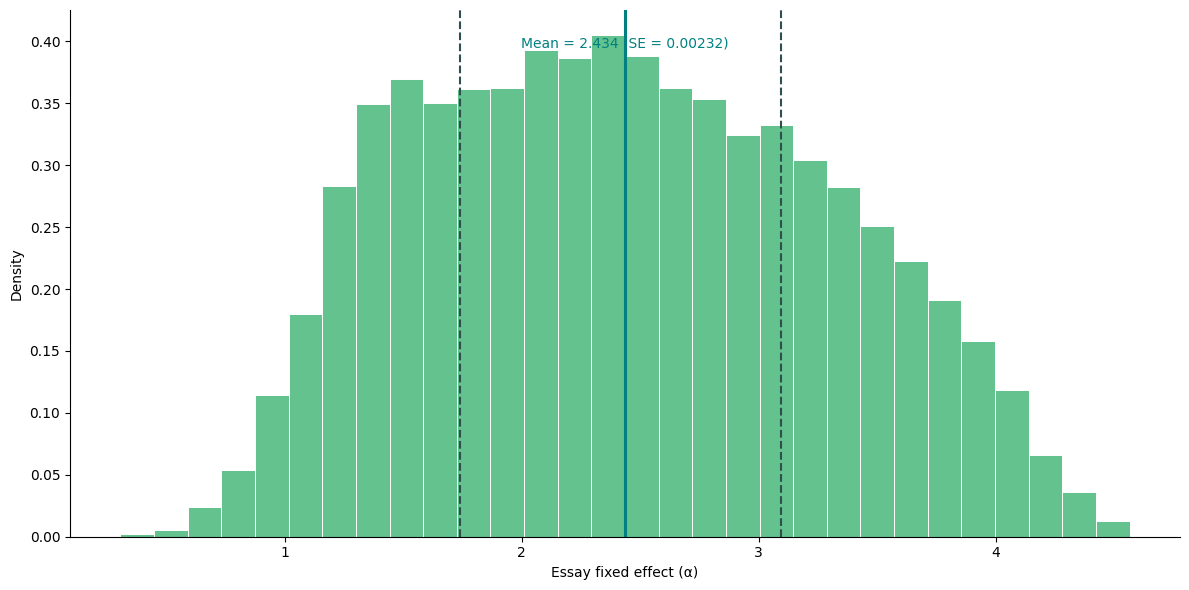

In [16]:
# Drop missing fixed effects (empirical Bayes correction)
x = df_decomp["fe_essay"].dropna()

# Compute stats
mean = x.mean()
se = x.std(ddof=1) / np.sqrt(len(x))
q1, q3 = np.percentile(x, [25, 75])

# --- Plot ---
plt.figure(figsize=FIG_SIZE)
sns.histplot(
    x,
    bins=30,
    color="mediumseagreen",
    stat="density",
    edgecolor="white",
    linewidth=0.7,
    alpha=0.8
)

# Quartile lines
plt.axvline(q1, color="darkslategray", linestyle="--", linewidth=1.5, label="Q1 / Q3")
plt.axvline(q3, color="darkslategray", linestyle="--", linewidth=1.5)

# Mean line (on top)
plt.axvline(mean, color="teal", linewidth=2.2, label="Mean")

# Text label
plt.text(mean, plt.ylim()[1]*0.95,
         f"Mean = {mean:.3f} (SE = {se:.5f})",
         ha="center", va="top", fontsize=10, color="teal")

# Labels and style
plt.xlabel("Essay fixed effect (α)")
plt.ylabel("Density")
sns.despine()
plt.tight_layout()
plt.savefig(f"{out_path}fixed_effect_distribution.pdf")
plt.show()


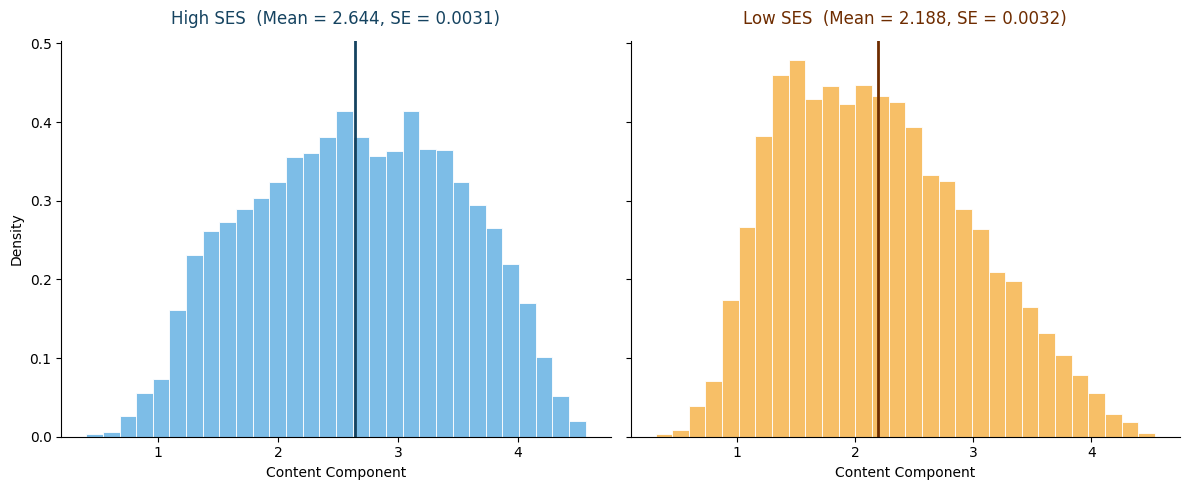

In [17]:
# Drop missing fixed effects
df_plot = df_decomp.dropna(subset=["fe_essay"])

# Split by SES
low_df  = df_plot[df_plot["low_SES"] == 1]["fe_essay"]
high_df = df_plot[df_plot["low_SES"] == 0]["fe_essay"]

# Helper to compute stats
def describe(x):
    return {
        "mean": x.mean(),
        "se": x.std(ddof=1) / np.sqrt(len(x)),
        "q1": np.percentile(x, 25),
        "q3": np.percentile(x, 75),
    }

stats_low  = describe(low_df)
stats_high = describe(high_df)

# --- Create side-by-side figure ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ---------- HIGH SES ----------
sns.histplot(
    high_df, bins=30, stat="density",
    color="#5DADE2", edgecolor="white", linewidth=0.6, alpha=0.8, ax=axes[0]
)
# axes[0].axvline(stats_high["q1"], color="#1B4F72", linestyle="--", linewidth=1)
# axes[0].axvline(stats_high["q3"], color="#1B4F72", linestyle="--", linewidth=1)
axes[0].axvline(stats_high["mean"], color="#154360", linewidth=2)

axes[0].set_title(
    f"High SES  (Mean = {stats_high['mean']:.3f}, SE = {stats_high['se']:.4f})",
    fontsize=12, color="#154360", pad=12
)
axes[0].set_xlabel("Content Component")
axes[0].set_ylabel("Density")

# ---------- LOW SES ----------
sns.histplot(
    low_df, bins=30, stat="density",
    color="#F5B041", edgecolor="white", linewidth=0.6, alpha=0.8, ax=axes[1]
)
# axes[1].axvline(stats_low["q1"], color="#784212", linestyle="--", linewidth=1)
# axes[1].axvline(stats_low["q3"], color="#784212", linestyle="--", linewidth=1)
axes[1].axvline(stats_low["mean"], color="#6E2C00", linewidth=2)

axes[1].set_title(
    f"Low SES  (Mean = {stats_low['mean']:.3f}, SE = {stats_low['se']:.4f})",
    fontsize=12, color="#6E2C00", pad=12
)
axes[1].set_xlabel("Content Component")
axes[1].set_ylabel("")

# --- Styling ---
for ax in axes:
    sns.despine(ax=ax)
    ax.axhline(0, color="gray", lw=0.5)

# fig.suptitle("Distribution of Essay Fixed Effects (α) by SES Group", fontsize=14, y=1.04)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}fixed_effect_distribution_by_SES_dual.pdf", bbox_inches="tight")
plt.show()

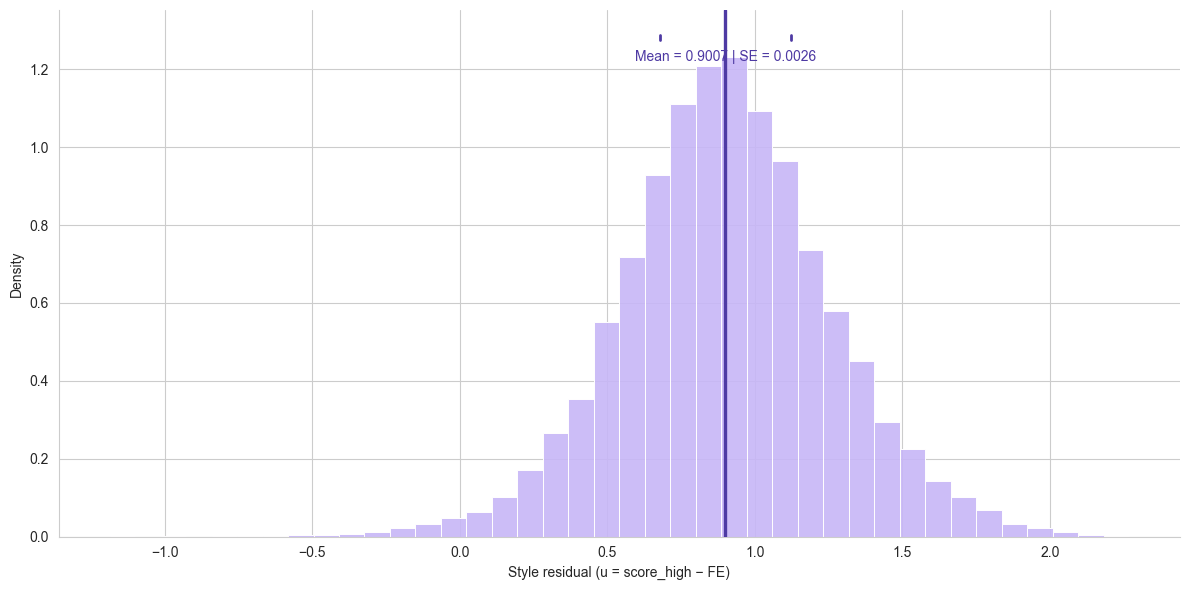

In [18]:
# --- Data (original essays only) ---
mask = (df_decomp["k"] == 0) & df_decomp["u"].notna()
u = df_decomp.loc[mask, "u"].astype(float)

# --- Stats ---
mean = u.mean()
q1, med, q3 = np.percentile(u, [25, 50, 75])
iqr = q3 - q1
se = u.std(ddof=1) / np.sqrt(len(u))  # standard error of the mean

plt.figure(figsize=FIG_SIZE)
sns.set_style("whitegrid")

# Histogram
sns.histplot(
    u, bins=40, stat="density",
    color="#C7B6F7", edgecolor="white", linewidth=0.7, alpha=0.9
)

# Quartile lines (visual guides only)
yl = plt.ylim()
# plt.axvline(q1, color="#4E3AA3", linestyle="--", linewidth=1.6, zorder=3)
# plt.axvline(q3, color="#4E3AA3", linestyle="--", linewidth=1.6, zorder=3)
plt.axvline(med, color="#4E3AA3", linewidth=2.4, zorder=4, label=f"SE = {se:.4f}")

# Tiny tick marks at top
top = yl[1]
for xline in (q1, med, q3):
    plt.plot([xline, xline], [top*0.985, top*0.995], color="#4E3AA3", linewidth=2, zorder=5, clip_on=False)

# --- Text annotation: now shows mean and SE ---
plt.text(
    mean, top*0.965,
    f"Mean = {mean:.4f} | SE = {se:.4f}",
    ha="center", va="top", fontsize=10, color="#4E3AA3"
)

# Labels / title
plt.xlabel("Style residual (u = score_high − FE)")
plt.ylabel("Density")
sns.despine()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}style_distribution.pdf")
plt.show()

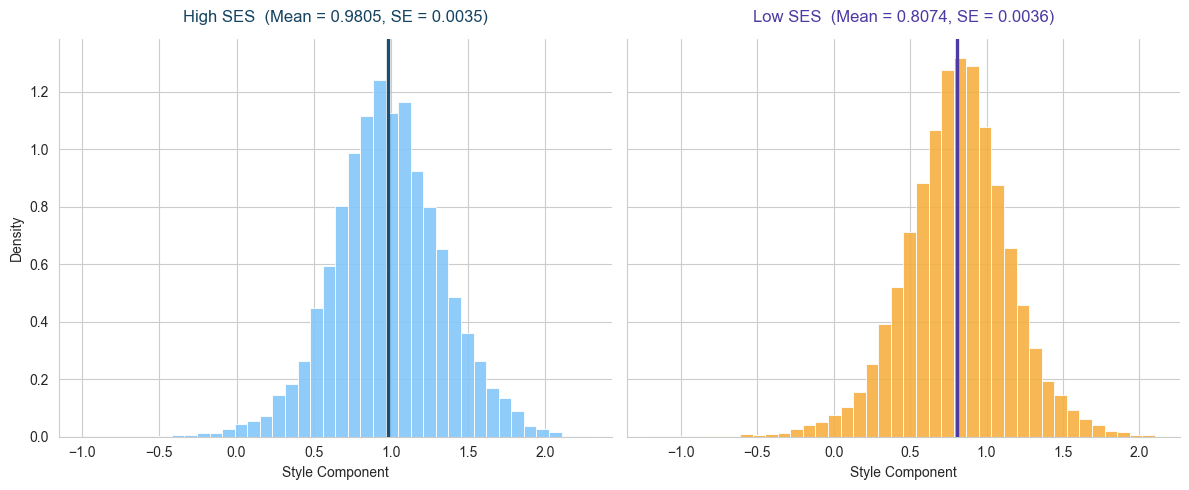

In [19]:
# --- Data (original essays only) ---
mask = (df_decomp["k"] == 0) & df_decomp["u"].notna()
df_u = df_decomp.loc[mask, ["low_SES", "u"]].astype(float)

# Split by SES q
u_high = df_u[df_u["low_SES"] == 0]["u"]
u_low  = df_u[df_u["low_SES"] == 1]["u"]

# --- Helper for summary stats ---
def describe(x):
    return {
        "mean": x.mean(),
        "se": x.std(ddof=1) / np.sqrt(len(x)),
        "q1": np.percentile(x, 25),
        "med": np.percentile(x, 50),
        "q3": np.percentile(x, 75),
    }

stats_high = describe(u_high)
stats_low  = describe(u_low)

# --- Plot setup ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.set_style("whitegrid")

# ---------- HIGH SES ----------
sns.histplot(
    u_high, bins=40, stat="density",
    color="#84C7F9", edgecolor="white", linewidth=0.6, alpha=0.9, ax=axes[0]
)
yl = axes[0].get_ylim()
# for val, ls, lw in zip(
#     [stats_high["q1"], stats_high["med"], stats_high["q3"]],
#     ["--", "-", "--"],
#     [1.6, 2.4, 1.6],
# ):
axes[0].axvline(stats_high['mean'], color="#1B4F72", linestyle="-", linewidth=2.4, zorder=3)
axes[0].set_title(
    f"High SES  (Mean = {stats_high['mean']:.4f}, SE = {stats_high['se']:.4f})",
    fontsize=12, color="#154360", pad=12
)
axes[0].set_xlabel("Style Component")
axes[0].set_ylabel("Density")

# ---------- LOW SES ----------
sns.histplot(
    u_low, bins=40, stat="density",
    color="#F5B041", edgecolor="white", linewidth=0.6, alpha=0.9, ax=axes[1]
)
# yl = axes[1].get_ylim()
# for val, ls, lw in zip(
#     [stats_low["q1"], stats_low["med"], stats_low["q3"]],
#     ["--", "-", "--"],
#     [1.6, 2.4, 1.6],
# ):
axes[1].axvline(stats_low['mean'], color="#4E3AA3", linestyle="-", linewidth=2.4, zorder=3)
axes[1].set_title(
    f"Low SES  (Mean = {stats_low['mean']:.4f}, SE = {stats_low['se']:.4f})",
    fontsize=12, color="#4E3AA3", pad=12
)
axes[1].set_xlabel("Style Component")
axes[1].set_ylabel("")

# --- Style ---
for ax in axes:
    sns.despine(ax=ax)
    ax.axhline(0, color="gray", lw=0.5)

# fig.suptitle("Distribution of Style Residuals (u) by SES Group", fontsize=14, y=1.04)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}style_distribution_by_SES_dual.pdf", bbox_inches="tight")
plt.show()

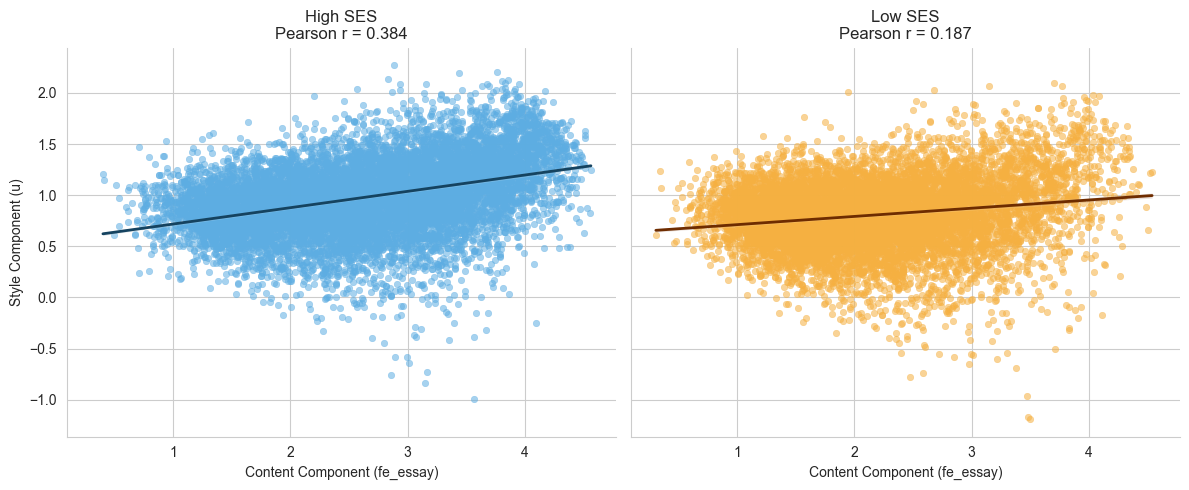

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional (for r and p-value). If you don't have scipy, see fallback below.
from scipy.stats import pearsonr

# --- Build a single plotting df where BOTH components exist on the same rows ---
df_scatter = df_decomp.loc[
    (df_decomp["k"] == 0) &
    df_decomp["u"].notna() &
    df_decomp["fe_essay"].notna(),
    ["low_SES", "u", "fe_essay"]
].astype(float).copy()

# Split by SES
df_high = df_scatter[df_scatter["low_SES"] == 0]
df_low  = df_scatter[df_scatter["low_SES"] == 1]

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

def panel(ax, d, title, point_color, line_color):
    # scatter
    sns.scatterplot(
        data=d, x="fe_essay", y="u",
        s=22, alpha=0.55, color=point_color, edgecolor=None, ax=ax
    )
    # regression line
    sns.regplot(
        data=d, x="fe_essay", y="u",
        scatter=False, ci=95, color=line_color, line_kws={"lw": 2}, ax=ax
    )

    # correlation
    r, p = pearsonr(d["fe_essay"].to_numpy(), d["u"].to_numpy())

    ax.set_title(f"{title}\nPearson r = {r:.3f}", fontsize=12)
    ax.set_xlabel("Content Component (fe_essay)")
    ax.set_ylabel("Style Component (u)")
    sns.despine(ax=ax)

panel(axes[0], df_high, "High SES", point_color="#5DADE2", line_color="#154360")
panel(axes[1], df_low,  "Low SES",  point_color="#F5B041", line_color="#6E2C00")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}style_vs_content_scatter_by_SES_dual.pdf", bbox_inches="tight")
plt.show()

In [21]:
COMP_ORDER = ["content", "style", "others"]
COMP_COLORS = {"content": "#84C7F9", "style": "#C7B6F7", "others": "#B6E3C7"}

# ---------- Core: compute shares ----------
def _mean_mask(s, mask):
    s2 = s[mask & s.notna()]
    return float(s2.mean()) if len(s2) else np.nan

def _compute_decomp(df_sub):
    m_orig = (df_sub["k"] == 0)
    m_hi = m_orig & (df_sub["low_SES"] == 0) & df_sub["score_high_full"].notna()
    m_lo = m_orig & (df_sub["low_SES"] == 1) & df_sub["score_low_full"].notna()
    if not (m_hi.any() and m_lo.any()):
        return pd.Series({c: np.nan for c in COMP_ORDER})

    mean_hi = _mean_mask(df_sub["score_high_full"], m_hi)
    mean_lo = _mean_mask(df_sub["score_low_full"], m_lo)
    total_gap = mean_hi - mean_lo

    content_hi = _mean_mask(df_sub["fe_essay"], m_orig & (df_sub["low_SES"] == 0))
    content_lo = _mean_mask(df_sub["fe_essay"], m_orig & (df_sub["low_SES"] == 1))
    style_hi   = _mean_mask(df_sub["u"], m_orig & (df_sub["low_SES"] == 0))
    style_lo   = _mean_mask(df_sub["u"], m_orig & (df_sub["low_SES"] == 1))

    content_gap = content_hi - content_lo
    style_gap   = style_hi   - style_lo
    others_gap  = total_gap - (content_gap + style_gap)

    if not total_gap:
        return pd.Series({c: np.nan for c in COMP_ORDER})

    return pd.Series({
        "content": content_gap / total_gap,
        "style":   style_gap   / total_gap,
        "others":  others_gap  / total_gap
    })

# ---------- Add grade_level to compute_decomp_shares ----------
def compute_decomp_shares(df_decomp):
    df = df_decomp.copy()

    groups = {"All": df}

    # by race / gender
    for g in ["race_white", "gender_male"]:
        if g in df.columns:
            groups[f"{g}=True"]  = df[df[g] == True]
            groups[f"{g}=False"] = df[df[g] == False]

    # by grade_level (NEW)
    if "grade_level" in df.columns:
        for gl in sorted(df["grade_level"].dropna().unique()):
            groups[f"grade_level={gl}"] = df[df["grade_level"] == gl]

    # by prompt
    if "prompt_name" in df.columns:
        for p in sorted(df["prompt_name"].dropna().unique()):
            groups[f"Prompt: {p}"] = df[df["prompt_name"] == p]

    out = pd.DataFrame({k: _compute_decomp(v) for k, v in groups.items()}).T
    return out.reindex(columns=COMP_ORDER)


# ---------- Plot helpers ----------
def plot_stacked(df_shares, title=None, figsize=(10,6), xtick_rotation=0, save_path=None, label_map=None):
    """
    Draw stacked bar chart of decomposition shares with nicer labels.
    """
    if df_shares.empty:
        print("No data to plot.")
        return

    # Apply mapping for nicer labels (default: GROUP_LABELS)
    if label_map is None:
        label_map = GROUP_LABELS
    df_plot = df_shares.copy()
    df_plot.index = df_plot.index.map(lambda x: label_map.get(x, x))

    ax = df_plot[COMP_ORDER].plot(
        kind="bar",
        stacked=True,
        color=[COMP_COLORS[c] for c in COMP_ORDER],
        edgecolor="white",
        linewidth=0.6,
        figsize=figsize
    )
    ax.set_ylabel("Share of Total SES Gap")
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.axhline(1, color="gray", lw=0.8, linestyle="--")
    if title:
        ax.set_title(title, pad=10)
    plt.xticks(rotation=xtick_rotation, ha="right" if xtick_rotation else "center")

    ax.legend(
        title="Component",
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path,  bbox_inches="tight")
    plt.show()


def plot_overview(decomp_shares, save_path=None, label_map=None):
    base = ["All", "race_white=True", "race_white=False", "gender_male=True", "gender_male=False"]
    grade_keys = sorted([i for i in decomp_shares.index if i.startswith("grade_level=")],key=lambda x: float(x.split("=")[1]))
    want = base + grade_keys  
    overview = decomp_shares.reindex(want).dropna(how="all")
    plot_stacked(overview, figsize=FIG_SIZE, xtick_rotation=45, save_path=save_path, label_map=label_map)


def plot_prompts(decomp_shares, save_path=None, label_map=None, figsize=(10,6)):
    prompts = decomp_shares.loc[decomp_shares.index.str.startswith("Prompt: ")].sort_index()
    h = max(5, 0.45 * len(prompts))
    plot_stacked(prompts, figsize=figsize, xtick_rotation=45, save_path=save_path, label_map=label_map)

In [22]:
# ---------- Group label mapping ----------
GROUP_LABELS = {
    "All": "All",
    "race_white=True": "White",
    "race_white=False": "Non-White",
    "gender_male=True": "Male",
    "gender_male=False": "Female",
    "grade_level=6.0": "Grade 6",
    "grade_level=8.0": "Grade 8",
    "grade_level=10.0": "Grade 10",
    "grade_level=11.0": "Grade 11",
}

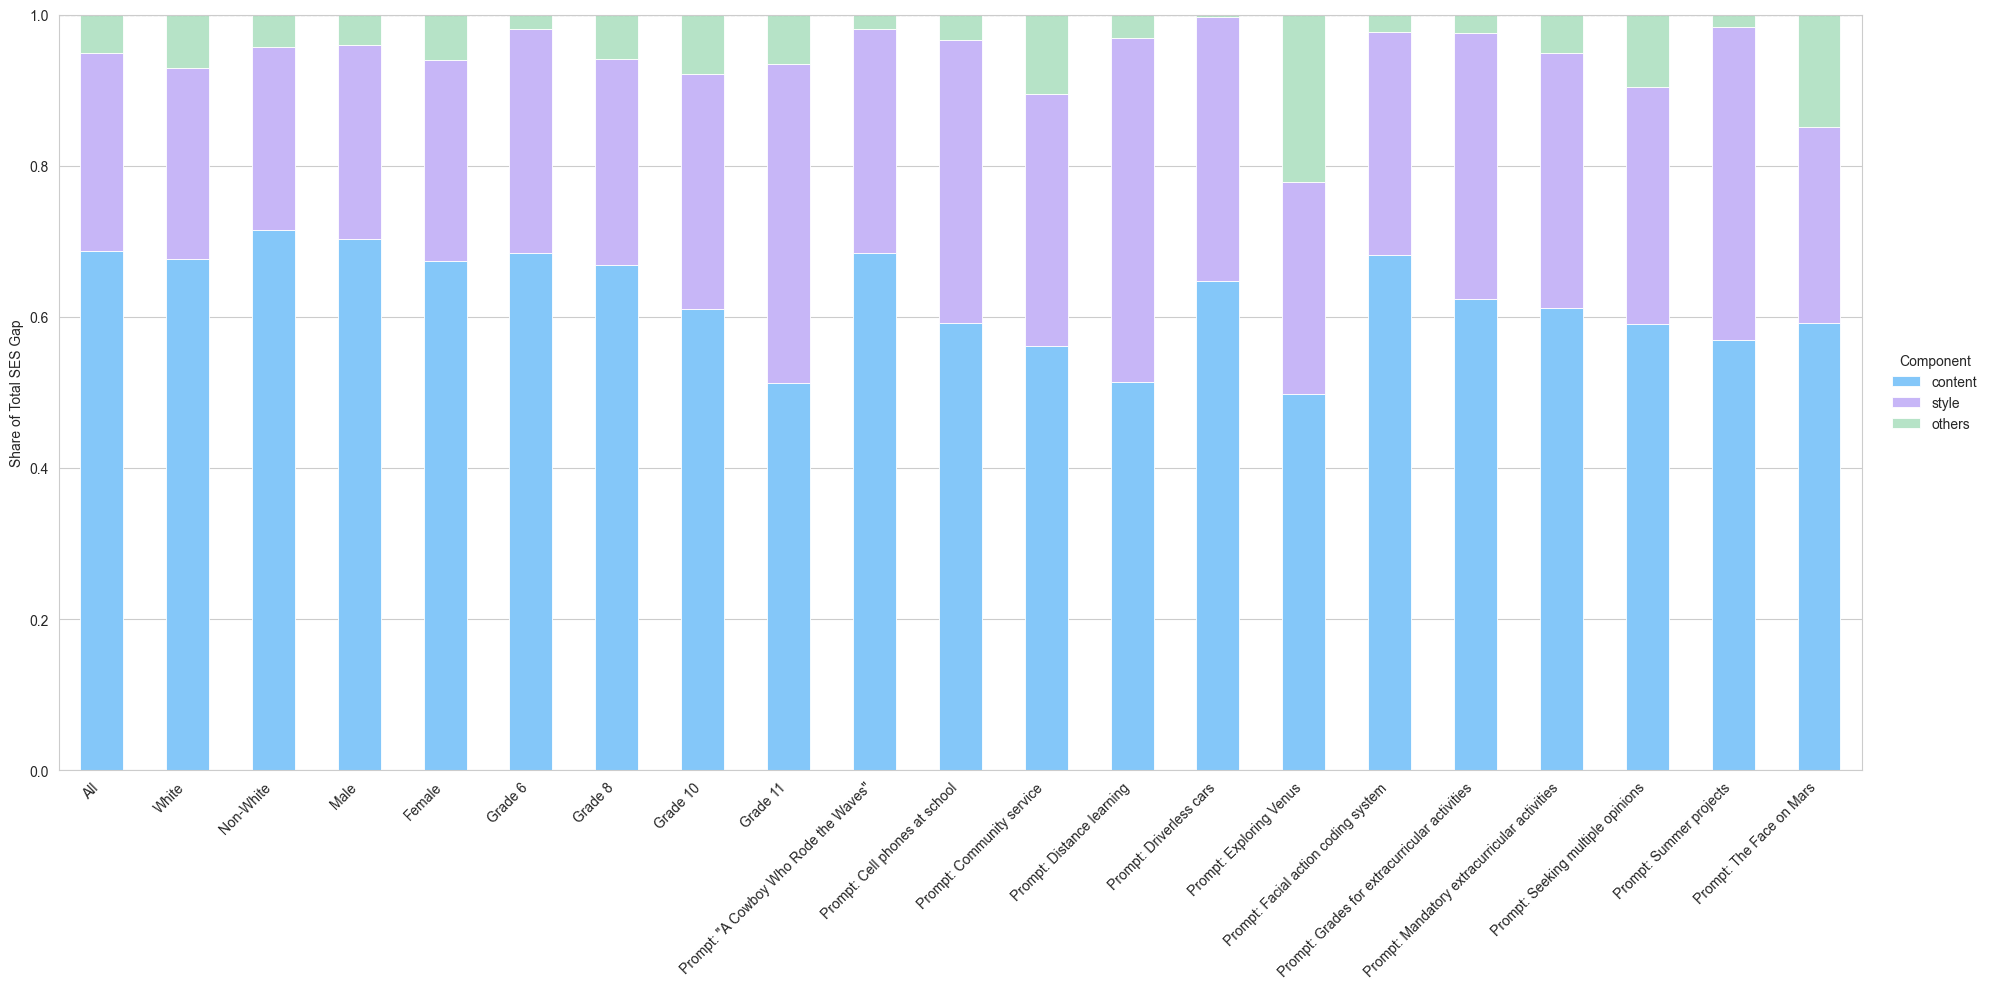

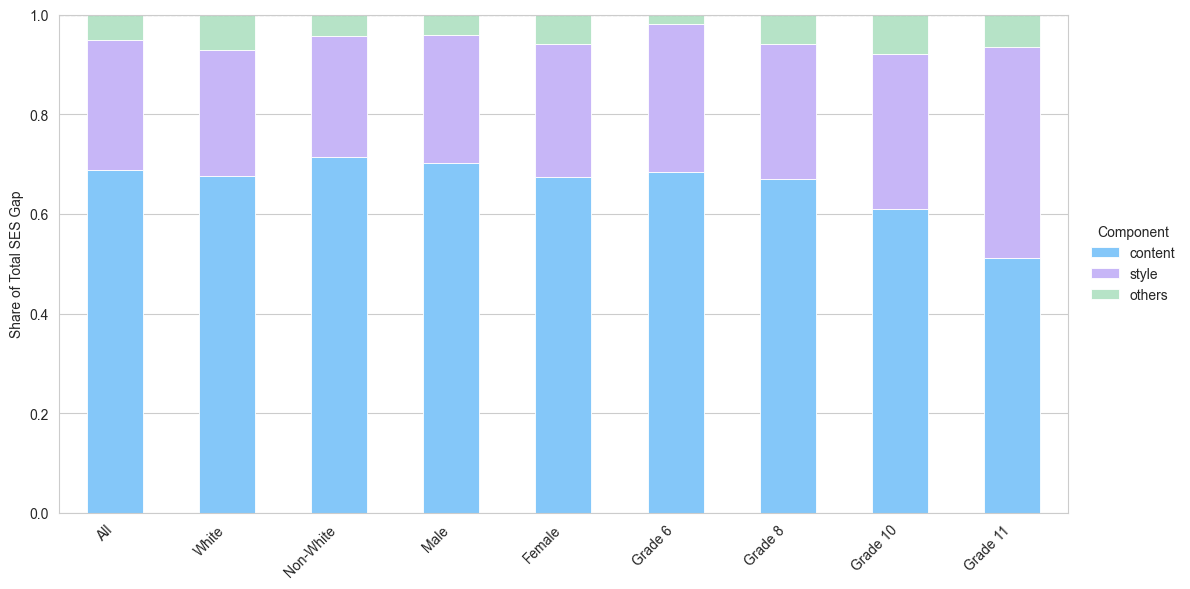

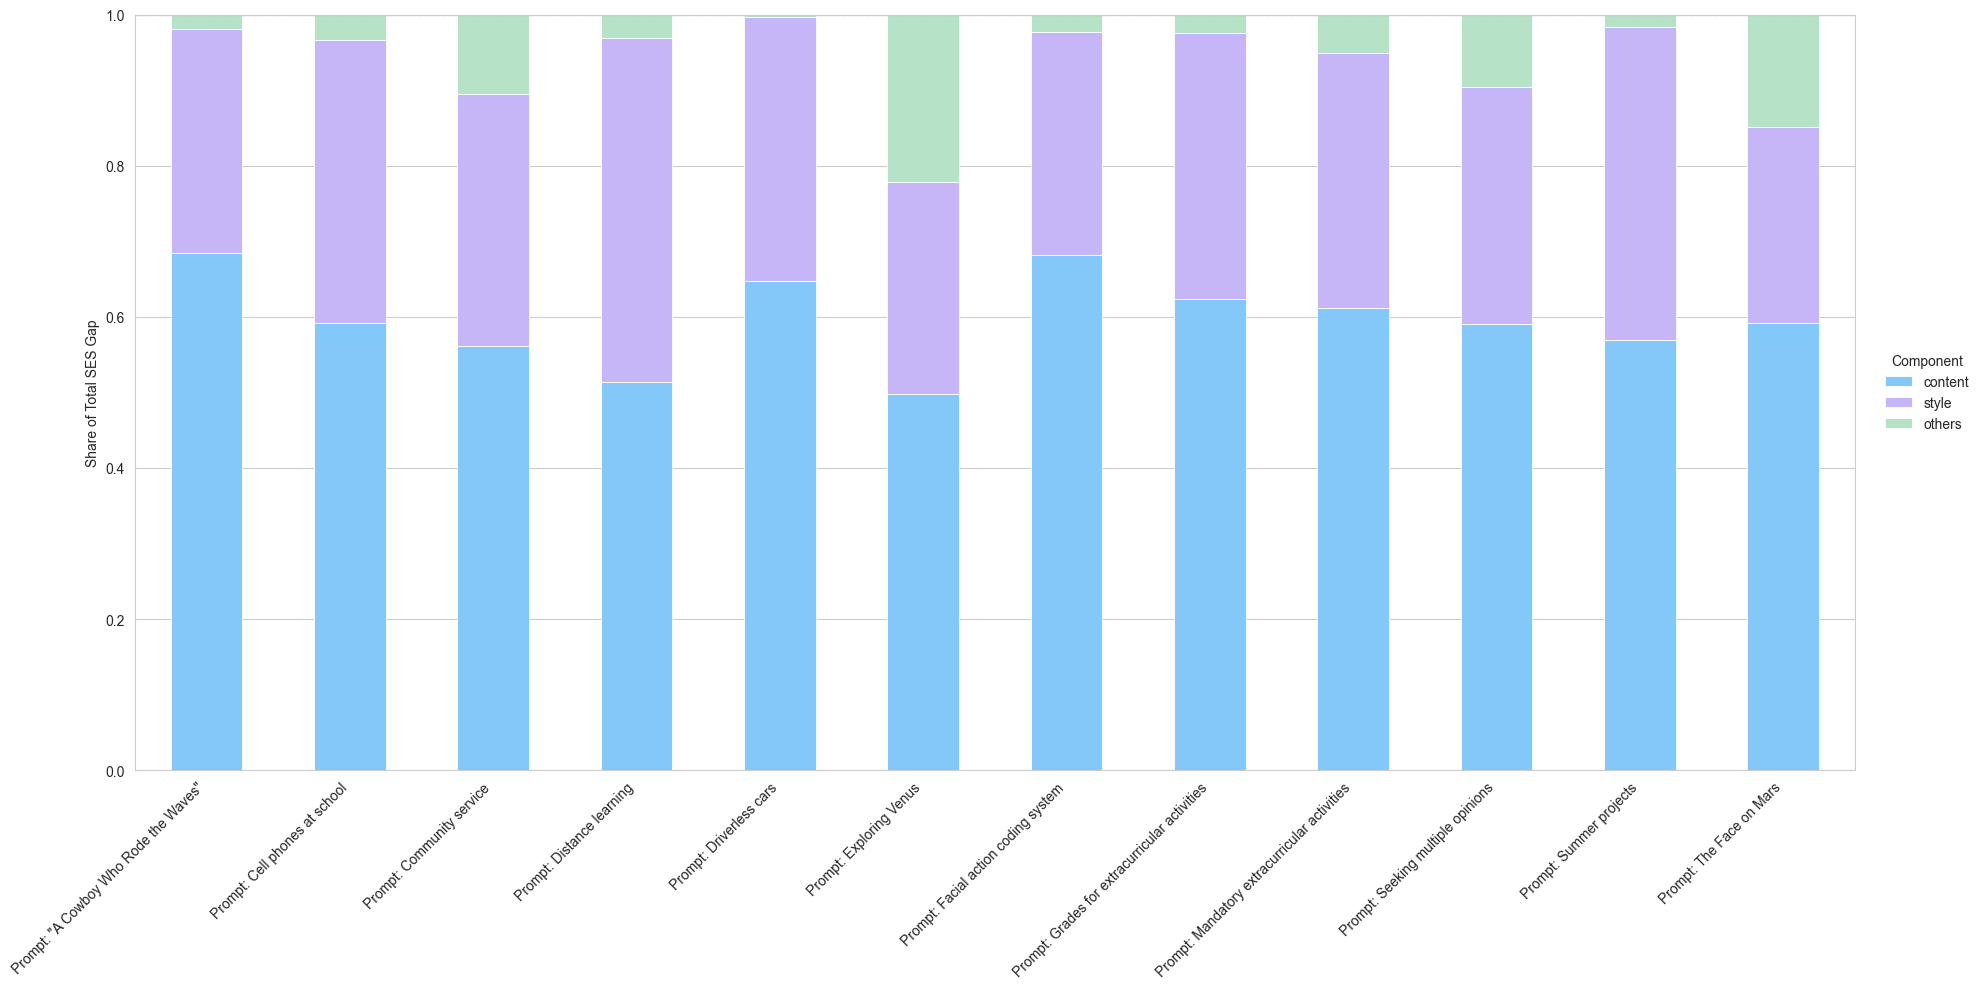

In [23]:
decomp_shares = compute_decomp_shares(df_decomp)

plot_stacked(
    decomp_shares,
    figsize=(20,10),
    xtick_rotation=45,
    save_path=f"{SAVE_DIR}decomp_shares_all.pdf",
    label_map=GROUP_LABELS
)

plot_overview(
    decomp_shares,
    save_path=f"{SAVE_DIR}decomp_shares_overview.pdf",
    label_map=GROUP_LABELS
)

plot_prompts(
    decomp_shares,
    figsize=(20,10),
    save_path=f"{SAVE_DIR}decomp_shares_prompts.pdf",
    label_map=GROUP_LABELS
)